## (0) Settings and Functions

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [8]:
df = pd.read_csv("../../data/feat/play_store_reviews_with_features.csv")

df['TEXT_LEMMA'] = (
    df['TEXT_LEMMA']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

df = df[df["EMOTION"] != "surprise"]

print(df.shape)
df.head(3)

(3006, 18)


,UNCLEAN_TEXT,TEXT_LEMMA,EMOTION,content,SENTIMENT,letter_count,sentence_count,avg_letter_per_word,words_per_sentence,avg_syllables_per_word,reading_time,punctuation_per_word,mean_verbs_per_word,mean_auxiliaries_per_word,mean_auxiliaries_per_sentence,flesch_portuguese,mean_unique_word_length,mean_char_repetition_per_word
0,app shope razoá apes fácil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...,sadness,app shope razoá apes fácil utiliz apresent alg...,positive,226.0,1.0,4.808511,47.0,1.595745,3.31994,0.0,0.148936,0.021277,0.333333,62.226383,4.829268,0.0
1,app bem otimiz fácil visual produt ped rastrei...,app bem otimiz facil visual produt ped rastrar...,sadness,app bem otimiz fácil visual produt ped rastrei...,positive,220.0,1.0,4.888889,45.0,1.711111,3.23180,0.0,0.177778,0.000000,0.000000,56.000000,4.945946,0.0
2,app bom prát fácil entend porém algum vend man...,app bom prat facil entend porem algum vend man...,sadness,app bom prát fácil entend porém algum vend man...,positive,159.0,1.0,4.184211,38.0,1.473684,2.33571,0.0,0.157895,0.000000,0.000000,80.374737,4.242424,0.0


In [9]:
def evaluate_on_test(pipe, X_train, y_train, X_test, y_test, le, model_name="model"):
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    metrics_df = pd.DataFrame({
        "Accuracy": [acc],
        "Precision (Macro)": [prec_macro],
        "Recall (Macro)": [rec_macro],
        "F1-score (Macro)": [f1_macro]
    })

    print("\n===== MÉTRICAS GLOBAIS =====")
    print(metrics_df.round(4))

    print("\n===== MÉTRICAS POR CLASSE =====")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    # remover linhas agregadas se quiser só classes
    report_df = report_df.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")

    # arredondar para 2 casas
    report_df = report_df.round(2)
    
    report_df.index = le.inverse_transform(report_df.index.astype(int))
    print(report_df)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Matriz de Confusão")
    plt.ylabel("Real")
    plt.xlabel("Predito")
    plt.show()

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)

        classes = np.unique(y_test)
        y_test_bin = label_binarize(y_test, classes=classes)

        plt.figure(figsize=(12, 10))

        for i, class_label in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Classe {class_label} (AUC = {roc_auc:.2f})")

        # micro-average
        fpr_micro, tpr_micro, _ = roc_curve(
            y_test_bin.ravel(),
            y_score.ravel()
        )
        auc_micro = auc(fpr_micro, tpr_micro)

        plt.plot(
            fpr_micro,
            tpr_micro,
            linestyle="--",
            label=f"Micro-average (AUC = {auc_micro:.2f})"
        )

        plt.plot([0, 1], [0, 1])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Curva ROC Multiclasse")
        plt.legend()
        plt.show()
    else:
        print("Modelo não possui predict_proba. ROC não calculada.")

    model_file = f"../../data/model/PlayStoreReviews_{model_name}.jolib"
    joblib.dump(pipe, model_file)

    print(f"\nModelo salvo em: {model_file}")

    metrics_df.to_csv(f"../../data/out/final/PlayStoreReviews_{model_name}_global_metrics.csv", index=False)

## (1) Predict Final

In [10]:
text_feature = "TEXT_LEMMA"

numerical_features = [
    'letter_count', 'avg_letter_per_word',
    'words_per_sentence', 'avg_syllables_per_word', 'reading_time',
    'mean_verbs_per_word', 'mean_auxiliaries_per_word',
    'mean_auxiliaries_per_sentence', 'flesch_portuguese',
    'mean_unique_word_length', 'mean_char_repetition_per_word'
]

cols_input = [text_feature] + numerical_features

X = df[cols_input]

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42,
    stratify=y
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42,
    stratify=y_aux
)

print(X_train.shape, X_dev.shape, X_test.shape)

(2104, 12) (451, 12) (451, 12)



===== MÉTRICAS GLOBAIS =====
   Accuracy  Precision (Macro)  Recall (Macro)  F1-score (Macro)
0    0.5965              0.451           0.457            0.4532

===== MÉTRICAS POR CLASSE =====
           precision  recall  f1-score  support
anger           0.64    0.58      0.61    112.0
disgust         0.58    0.58      0.58    142.0
fear            0.00    0.00      0.00      7.0
happiness       0.60    0.69      0.64     48.0
neutral         0.25    0.23      0.24     13.0
sadness         0.63    0.66      0.65    129.0


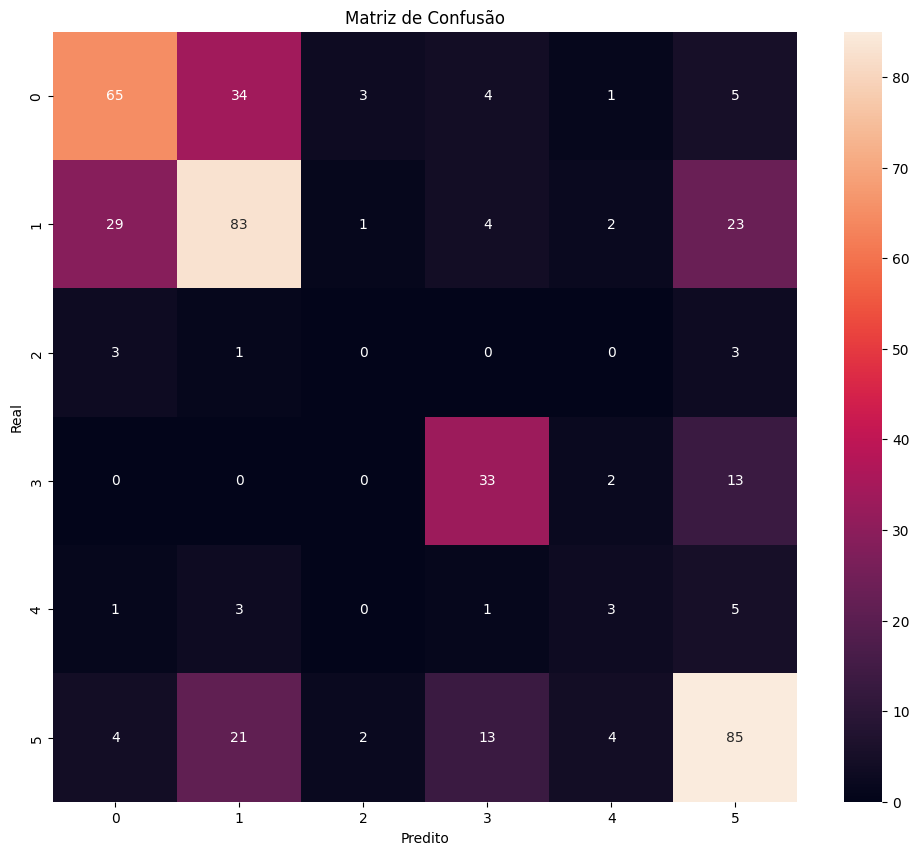

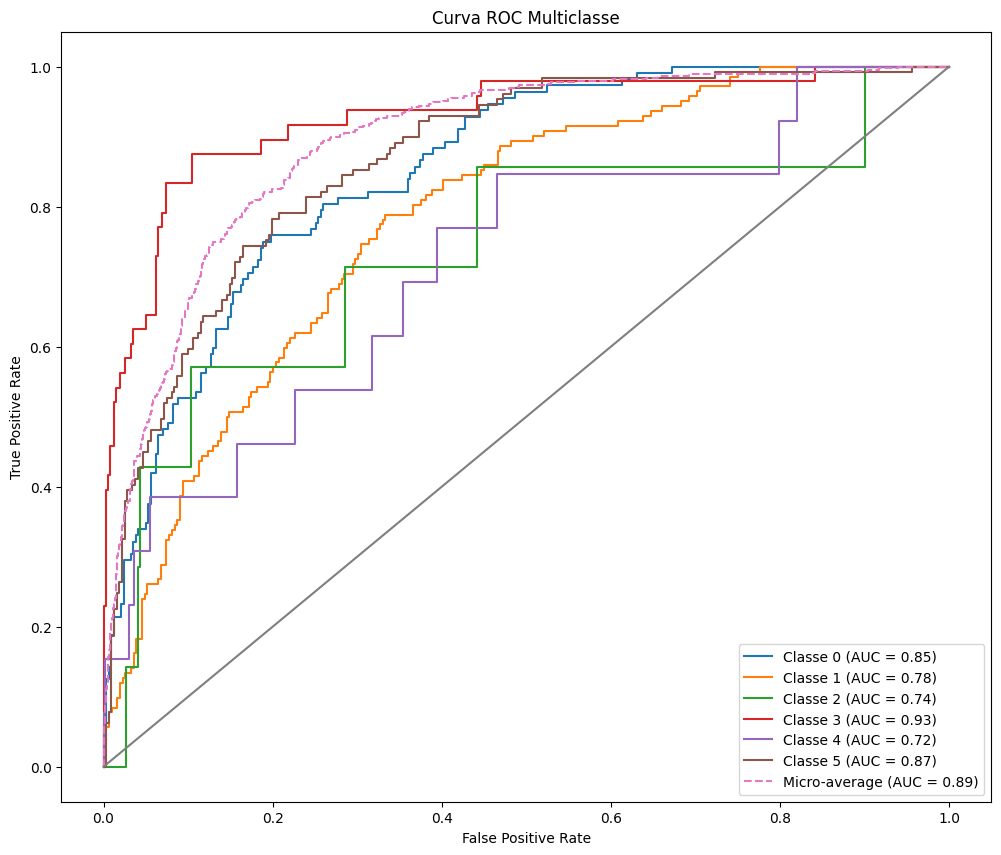


Modelo salvo em: ../../data/model/PlayStoreReviews_LogisticRegression_TFIDF.jolib


In [11]:
model = LogisticRegression(max_iter=1000, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(), text_feature),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", model)
])

evaluate_on_test(pipe, X_train, y_train, X_test, y_test, le, model_name="LogisticRegression_TFIDF")